## DAY 3 Evaluation, Baselines, Traditional ML

In [ ]:
import random
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor
from pricer.evaluator import evaluate
from pricer.items import Item

In [ ]:
LITE_MODE = False

In [ ]:
username = "ed_donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train)} training items,{len(val)} validation items,{len(test)} test items")

In [ ]:
def random_pricer(item):
    return random.randrange(1,1000)

In [ ]:
random.seed(42)
evaluate(random_pricer,test)

In [ ]:
# That was cool!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices)/len(training_prices)

print(training_average)

def constant_pricer(item):
    return training_average

In [ ]:
evaluate(constant_pricer,test)



In [ ]:
def get_features(item):
    return {"weight":item.weight,
            "weight_unknown": 1 if item.weight ==0 else 0,
            "text_length":len(item.summary)}


In [ ]:
def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df["price"] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test)

In [ ]:
# We can Use This code as it is
# No need to cram it
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'weight_unknown', 'text_length']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

In [ ]:
def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]


In [ ]:
evaluate(linear_regression_pricer,test)

In [ ]:
prices = np.array([float(item.price) for item in train])
documents = [item.summary for item in train]

In [ ]:
np.random.seed(42)
vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(documents)

In [ ]:
# Here are the 1,000 most common words that it picked, not including "stop words":

selected_words = vectorizer.get_feature_names_out()
print(f"Number of selected words: {len(selected_words)}")
print("Selected words:", selected_words[1000:1020])

In [ ]:
regressor = LinearRegression()
regressor.fit(X, prices)

In [ ]:
def natural_language_linear_regression_pricer(item):
    x = vectorizer.transform([item.summary])
    return max(regressor.predict(x)[0], 0)

In [ ]:
evaluate(natural_language_linear_regression_pricer, test)

## Random Forest model

The Random Forest is a type of "**ensemble**" algorithm, meaning that it combines many smaller algorithms to make better predictions.

It uses a very simple kind of machine learning algorithm called a **decision tree**. A decision tree makes predictions by examining the values of features in the input. Like a flow chart with IF statements. Decision trees are very quick and simple, but they tend to overfit.

In our case, the "features" are the elements of the Vector - in other words, it's the number of times that a particular word appears in the product description.

So you can think of it something like this:

**Decision Tree**
\- IF the word "TV" appears more than 3 times THEN
-- IF the word "LED" appears more than 2 times THEN
--- IF the word "HD" appears at least once THEN
---- Price = $500


With Random Forest, multiple decision trees are created. Each one is trained with a different random subset of the data, and a different random subset of the features. You can see above that we specify 100 trees, which is the default.

Then the Random Forest model simply takes the average of all its trees to product the final result.

In [ ]:
def random_forest(item):
    x = vectorizer.transform([item.summary])
    return max(0, rf_model.predict(x)[0])


In [ ]:
evaluate(random_forest, test)

In [ ]:
# This is how to save the model if you want to, particularly if you run this on a larger dataset

# import joblib
# joblib.dump(rf_model, "random_forest.joblib")

## Introducing XGBoost

Like Random Forest, XGBoost is also an ensemble model that combines multiple decision trees.

But unlike Random Forest, XGBoost builds one tree after another, with each next tree correcting for errors in the prior trees, using 'gradient descent'.

It's much faster than Random Forest, so we can run it for the full dataset, and it's typically better at generalizing.

**If this import doesn't work, please skip this! It's not required. On a Mac, you might need to do `brew install libomp` in the terminal.**

In [ ]:
import xgboost as xgb

In [ ]:
np.random.seed(42)

xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42, n_jobs=4, learning_rate=0.1)
xgb_model.fit(X, prices)

In [ ]:
def xg_boost(item):
    x = vectorizer.transform([item.summary])
    return max(0, xgb_model.predict(x)[0])

In [ ]:
evaluate(xg_boost, test)

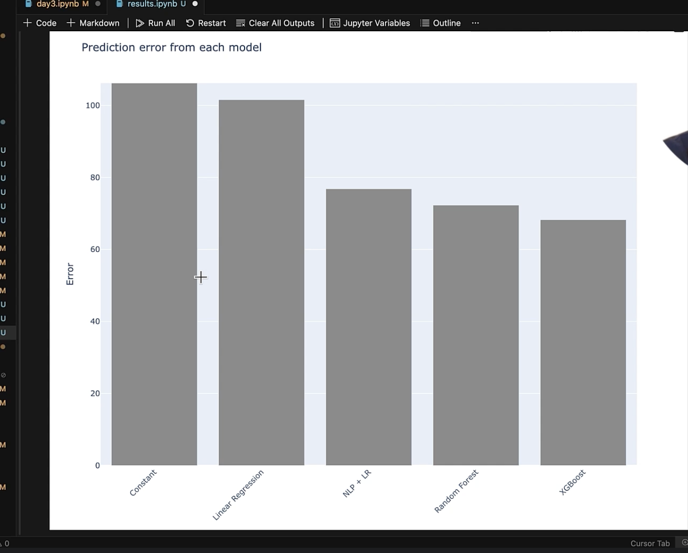